Utforska hur Python kod för ett DCIM relativt inläsning loggning larmning och felhantering 


In [88]:
# PAKET OCH MODULER SOM BEHÖVER IMPORTERAS 

import csv
from datetime import datetime
from enum import Enum
import logging
import matplotlib.pyplot as plt # Tredjeparsbibliotek, installeras via pip install 
import os
import random
import time

# DEL 1: Förflytta och förändra data.

Mål: Skapa en CSV fil med servrar som ska in i DCIM.
Metod: Gör en """multistring""" lista med server data.
Skriv server datat till filen server.csv.
Resultat: En csv fil med 20st server objekt.

In [89]:
csv_data = """Web-Server-01,192.168.1.10,16
Web-Server-02,192.168.1.11,16
Web-Server-03,192.168.1.12,8
App-Server-01,192.168.1.13,32
App-Server-02,192.168.1.14,32
App-Server-03,192.168.1.15,16
DB-Master-01,192.168.1.16,64
DB-Slave-01,192.168.1.17,32
DB-Slave-02,192.168.1.18,32
Backup-Server,192.168.1.19,8
Proxy-01,192.168.1.20,4
Proxy-02,192.168.1.21,4
Auth-Server,192.168.1.22,8
DNS-Server-01,192.168.1.23,4
DNS-Server-02,192.168.1.24,4
Monitoring-01,192.168.1.25,16
Storage-01,192.168.1.26,12
Storage-02,192.168.1.27,12
Dev-Server-01,192.168.1.28,8
Test-Server-01,192.168.1.29,4"""

with open("server.csv", "w", encoding="utf-8") as file:
    file.write(csv_data.strip())

print("En seed file för att populera datacenter med 20 enheter har skapats")

En seed file för att populera datacenter med 20 enheter har skapats


Mål: Skapa Parent/Child klasser för all hårdvara såsom servrar.
Metod: Definiera upp klasserna (ritningen) med metoder och attribut.
Resultat. Klasser redo att instansera hårdvaru objekt såsom servrar

In [90]:
# Parent/Child klasser

class Hardware:
    def __init__(self, name: str, ip_address: str):
        self.name = name
        self.ip_address = ip_address
        self.status = "OK" 
        
class Server(Hardware):
    def __init__(self, name: str, ip_address: str, cpu_cores: int):
        super().__init__(name, ip_address)
        self.cpu_cores = cpu_cores

print("Parent Klass Hardware och Child  Klass Server har nu definierats i en första version")

Parent Klass Hardware och Child  Klass Server har nu definierats i en första version


Mål: Utforska inläsning av CSV filen server.csv till internminnet på DCIM  
Metod: Parsa serverdatat från csv filen till en python Lista 
Resultat: Listan inventory[] i DCIM internminnet fylls med serverdata.

In [91]:
inventory = []

with open("server.csv", "r", encoding ="utf-8") as file:
    reader = csv.reader(file)
    for row in reader:
        server_object = Server(name=row[0], ip_address=row[1], cpu_cores=int(row[2]))
        inventory.append(server_object)
        
print(f"totalt antal inlästa server objekt är {len(inventory)}")
 

totalt antal inlästa server objekt är 20


Mål: Läsa ut serverdata från internminnet. Lista  i internminnet. SV 
Metod: Läs data från listan inventory[]
Resultat: Skriver ut innehåll från inventory[] till terminalfönstret.

In [92]:
print("läser vad som finns på rad två i listan (index startar från 0)")
print(f"namnet är:{inventory[1].name} IP är:{inventory[1].ip_address} antal cpu är {inventory[1].cpu_cores}")
print("\nläser innehållet i de tre första raderna i listan")
for srv in inventory[:3]:
    print(f"namnet är: {srv.name} IP är: {srv.ip_address} antal cpu är: {srv.cpu_cores}")        



läser vad som finns på rad två i listan (index startar från 0)
namnet är:Web-Server-02 IP är:192.168.1.11 antal cpu är 16

läser innehållet i de tre första raderna i listan
namnet är: Web-Server-01 IP är: 192.168.1.10 antal cpu är: 16
namnet är: Web-Server-02 IP är: 192.168.1.11 antal cpu är: 16
namnet är: Web-Server-03 IP är: 192.168.1.12 antal cpu är: 8


Mål:    Öka antal cpu i ett server objekt i inventory[].
        Sätt status till "Warning" på de tre första serverobjekten.
        Uppdatera alla serverobjekt med status "Warning" till status "CRITICAL"
Metod:  Varje server har ett antal rader index 0-19. Och ett antal kolumner 
        såsom status och antal cpu
Resultat: Ändringen av värden i listan görs genom att ett anrop skriva en ändring till rätt index och rätt kolumn

In [93]:
# --- FÖRÄNDRA ETT OBJEKT I LISTAN ---

print(f"vi ändrar antal cpu i Web-Server-3 från {inventory[2].cpu_cores} till {2*inventory[2].cpu_cores}")
#ws_3 = Web-Server-3 och den ska få utökat antal cpu.
# det står inventory[2] pga att index börjar på 0.
ws_3 = inventory[2]
ws_3.cpu_cores = 2*inventory[2].cpu_cores 
print(f"{ws_3.name} har nu {ws_3.cpu_cores} cpu kärnor ")

# Sätt status på de tre första server objekten till "Warning"
for rader in inventory[:3]:
    rader.status = "Warning"
    print (rader.status, rader.name, rader.cpu_cores)   

# Gå igenom hela listan med serverobjekt och ändra de serverobjekt 
# som har status "Warning" till status "CRITICAL"

for rader in inventory[:]:
    if rader.status == "Warning":
        rader.status = "CRITICAL"
        print(rader.status, rader.name, rader.cpu_cores)  
    
 

vi ändrar antal cpu i Web-Server-3 från 8 till 16
Web-Server-03 har nu 16 cpu kärnor 
Warning Web-Server-01 16
Warning Web-Server-02 16
Warning Web-Server-03 16
CRITICAL Web-Server-01 16
CRITICAL Web-Server-02 16
CRITICAL Web-Server-03 16


Mål: varje server skall få en unik ID tagg (IT-01, IT-02 osv)  
Metod: subklassen Server anropar basklassen Hardware vid instansering av NY server
Varje NY instans av server objekt får ett unikt ID när __init__ körs
Resultat: Endast NYA eller OMINSTANSERADE servrar får ett unikt ID 

In [94]:
id_counter = 1

class Hardware:
    def __init__(self, name: str, ip_address: str):
        global id_counter
        # varje NY instans får ett unikt ID när __init__ körs
        self.id_tag = f"ID-{id_counter}"
        id_counter += 1
        
        self.name = name
        self.ip_address = ip_address
        self.status = "OK"
        
        
class Server(Hardware):
    def __init__(self, name: str, ip_address: str, cpu_cores: int):
        # super() anropar Hardware.__init__ som sätter id_tag, name, ip_adress och status
        super().__init__(name, ip_address)
        self.cpu_cores = cpu_cores
        

inventory = []

with open("server.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    
    for row in reader:
        # När server() anropas körs __init__ så att id_tag skapas automatiskt
        server_object = Server(name=row[0], ip_address=row[1], cpu_cores=int(row[2]))
        inventory.append(server_object)
    

for srv in inventory:
    print(f"{srv.id_tag} {srv.name}")
    
print("Nu har alla servrar id taggats via en ny attribut och metod i Parent Class hardware")

ID-1 Web-Server-01
ID-2 Web-Server-02
ID-3 Web-Server-03
ID-4 App-Server-01
ID-5 App-Server-02
ID-6 App-Server-03
ID-7 DB-Master-01
ID-8 DB-Slave-01
ID-9 DB-Slave-02
ID-10 Backup-Server
ID-11 Proxy-01
ID-12 Proxy-02
ID-13 Auth-Server
ID-14 DNS-Server-01
ID-15 DNS-Server-02
ID-16 Monitoring-01
ID-17 Storage-01
ID-18 Storage-02
ID-19 Dev-Server-01
ID-20 Test-Server-01
Nu har alla servrar id taggats via en ny attribut och metod i Parent Class hardware


Mål: varje server skall få en unik ID tagg (IT-01, IT-02 osv)  
Metod: Nu ska vi göra samma sak men genom att arbeta med listan i minnet och 
utöka med en label som heter id_tag, och inte bara instansera om alla objekt 
Resultat: servrar i minnet ska inte behöva instanseras om.

In [95]:
inventory = []
with open("server.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    for row in reader:    
        server_object = Server(name=row[0], ip_address=row[1], cpu_cores=int(row[2]))
        inventory.append(server_object)

print("Testar att skriva ut rad 3 för att verifiera att en lista skapats i minnet")
print (inventory[2].name)


Testar att skriva ut rad 3 för att verifiera att en lista skapats i minnet
Web-Server-03


...forts Metod:
Lägger till en klassvariabel i listan med de 
instanserade servrarna som redan ligger i minnet!
Sätter en klassvariabel DIREKT på Parent Class Hardware
--hardware.datacenter_site = "DC_STOCKHOLM_ZONE_1"--
...forts Resultat: Nu finns denna egenskap, dvs label sitenamn för varje server, AUTOMATISKT tillagd i samtliga serverobjekt i minnet 

In [96]:
print("Vi sätter den nya klassvariabeln datacenter_site till DC_STOCKHOLM_ZONE_1")
Hardware.datacenter_site = "DC_STOCKHOLM_ZONE_1"

print("Testar att skriva ut rad 3 för att verifiera att klassvariabeln skapats i minnet")
print (inventory[2].datacenter_site)

Vi sätter den nya klassvariabeln datacenter_site till DC_STOCKHOLM_ZONE_1
Testar att skriva ut rad 3 för att verifiera att klassvariabeln skapats i minnet
DC_STOCKHOLM_ZONE_1


Mål: Ytterligare en ny variant att lägga till id_tagg till listan med de 
instanserade servrarna som redan ligger i minnet.
Metod: Detta genom en for loop som säkerhetstaggar BEFINTLIG population, alltså instasieras ICKE en ny serverpopulation.
Resultat: Stegat igenom listan i minnet och satt en ny instansvariabel 
(.security_tag) på servrarna i minnet.

In [97]:
# 1. LOOPA IGENOM ALLA SERVRAR OCH SÄTT TAGGEN
for server in inventory:
    if server.cpu_cores >= 32:
        server.security_tag = "High_Risk"
    elif server.cpu_cores >= 16:
        server.security_tag = "Medium_Risk"
    else:
        server.security_tag = "Low_Risk"

# 2. SKRIV UT DE 8 FÖRSTA SERVRARNA
print(f"{'NAMN':<15} | {'CPU':<5} | {'SÄKERHETSTAGG'}")
print("-" * 40)

for srv in inventory[:8]:
    print(f"{srv.name:<15} | {srv.cpu_cores:<5} | {srv.security_tag}")

NAMN            | CPU   | SÄKERHETSTAGG
----------------------------------------
Web-Server-01   | 16    | Medium_Risk
Web-Server-02   | 16    | Medium_Risk
Web-Server-03   | 8     | Low_Risk
App-Server-01   | 32    | High_Risk
App-Server-02   | 32    | High_Risk
App-Server-03   | 16    | Medium_Risk
DB-Master-01    | 64    | High_Risk
DB-Slave-01     | 32    | High_Risk


Mål: I detta exempel baseras security_tag på hårdvarukapacitet (CPU), medan warning_tag baseras på en helt annan regel (t.ex. om servern har för lite RAM-minne för sin CPU-kraft):
Metod: Warning Tag och Secutiry tag sätts nu i Server class.

In [98]:
class Hardware:

    def __init__(
        self, name: str, ip_address: str, power_watts: int, asset_tag: str = ""
    ):
        self.name = name
        self.ip_address = ip_address
        self.power_watts = power_watts
        self.asset_tag = asset_tag
        self.status = "OK"


class Server(Hardware):

    def __init__(
        self,
        name: str,
        ip_address: str,
        power_watts: int,
        cpu_cores: int,
        ram_gb: int,
        asset_tag: str = "",
    ):
        # 1. Anropa parent-klassen med super()
        super().__init__(name, ip_address, power_watts, asset_tag)

        # 2. Grundläggande specifikationer
        self.cpu_cores = cpu_cores
        self.ram_gb = ram_gb

        # 3. TAGG 1: Security Tag (Baserat på CPU-kärnor / Riskprofil)
        if self.cpu_cores >= 32:
            self.security_tag = "High_Risk"
        elif self.cpu_cores >= 16:
            self.security_tag = "Medium_Risk"
        else:
            self.security_tag = "Low_Risk"

        # 4. TAGG 2: Warning Tag (Baserat på resursbalans / Varningar)
        # Regel: Om vi har mycket CPU (>=16) men lite RAM (<32GB) varnar vi för flaskhals
        if self.cpu_cores >= 16 and self.ram_gb < 32:
            self.warning_tag = "RAM_BOTTLENECK_WARNING"
        elif self.power_watts > 600:
            self.warning_tag = "HIGH_POWER_WARNING"
        else:
            self.warning_tag = "NO_WARNING"


# =====================================================================
# TESTA ATT SKAPA OCH SKRIVA UT SERVRARNA
# =====================================================================

inventory = [
    Server(
        "Web-Server-01",
        "192.168.1.10",
        power_watts=400,
        cpu_cores=16,
        ram_gb=16,
        asset_tag="HW-1",
    ),  # RAM-flaskhals!
    Server(
        "App-Server-01",
        "192.168.1.20",
        power_watts=750,
        cpu_cores=32,
        ram_gb=128,
        asset_tag="HW-2",
    ),  # Hög strömförbrukning!
    Server(
        "Test-Server-01",
        "192.168.1.30",
        power_watts=200,
        cpu_cores=4,
        ram_gb=16,
        asset_tag="HW-3",
    ),  # Helt OK
]

print(
    f"{'NAMN':<15} | {'SECURITY TAG':<13} | {'WARNING TAG':<23} | {'POWER'}"
)
print("-" * 65)

for srv in inventory:
    print(
        f"{srv.name:<15} | {srv.security_tag:<13} | {srv.warning_tag:<23} | {srv.power_watts}W"
    )

NAMN            | SECURITY TAG  | WARNING TAG             | POWER
-----------------------------------------------------------------
Web-Server-01   | Medium_Risk   | RAM_BOTTLENECK_WARNING  | 400W
App-Server-01   | High_Risk     | HIGH_POWER_WARNING      | 750W
Test-Server-01  | Low_Risk      | NO_WARNING              | 200W


Resultat:
Måste här instansera om server objekten vid tillägg av taggar såsom security tag och warning tag.
Därför behov av att frångå dessa "hårdkodade" taggar som kräver ominstansering och i stället titta på dynamiska set med taggar på levande objekt. 
men...

Att kasta in fridrivande textsträngar i en set() eller ändra godtyckliga variabler under drift kallas i branschen för "Magic Strings" och "Unstructured State". Det är en känd källa till buggar eftersom stavfel (t.ex. "GOLD_SLA" vs "gold_sla") inte upptäcks av Python och det finns ingen validering.

För ett stabilt, professionellt och lättunderhållet DCIM-system finns det två betydligt bättre och renare arkitekturmönster.

Det Bästa Alternativet: Beräknade Egenskaper (@property)
Istället för att spara en sekundär tagg eller variabel i minnet och behöva "uppdatera" den manuellt när saker ändras, beräknar vi statusen dynamiskt när någon ber om den.

Varför detta är överlägset:
Single Source of Truth: Du har bara en sanningskälla (förhållandet mellan cpu_cores och ram_gb).

Noll synkroniseringsfel: Du kan aldrig glömma att uppdatera taggen – den räknas ut exakt i samma stund du frågar efter den.

Ingen minnesbelastning: Inga extra variabler eller listor sparas på objektet.

Kodexempel: Rent & Stabilt med @property
OBSERVERA EXTRA NOGA @property dekoratorn

In [99]:
class Hardware:

    def __init__(
        self, 
        name: str, 
        ip_address: str, 
        power_watts: int, 
        asset_tag: str = ""
    ):
        self.name = name
        self.ip_address = ip_address
        self.power_watts = power_watts
        self.asset_tag = asset_tag
        self.status = "OK"


class Server(Hardware):

    def __init__(
        self,
        name: str,
        ip_address: str,
        power_watts: int,
        cpu_cores: int,
        ram_gb: int,
        asset_tag: str = "",
    ):
        super().__init__(name, ip_address, power_watts, asset_tag)
        self.cpu_cores = cpu_cores
        self.ram_gb = ram_gb

    # --- BERÄKNADE EGENSKAPER (COMPUTED PROPERTIES) ---

    @property
    def security_level(self) -> str:
        """Räknar ut säkerhetsklass dynamiskt baserat på hårdvarans tillstånd."""
        if self.cpu_cores >= 32:
            return "HIGH_RISK"
        elif self.cpu_cores >= 16:
            return "MEDIUM_RISK"
        return "LOW_RISK"

    @property
    def has_bottleneck(self) -> bool:
        """Kollar om servern har för lite RAM i förhållande till sina CPU-kärnor."""
        return self.cpu_cores >= 16 and self.ram_gb < 32


# =====================================================================
# TESTA I DRIFT
# =====================================================================

# 1. Vi skapar 3 servrar i drift
inventory = [
    Server("Web-01", "192.168.1.10", 400, cpu_cores=16, ram_gb=16, asset_tag="HW-1"),
    Server("App-01", "192.168.1.20", 750, cpu_cores=32, ram_gb=128, asset_tag="HW-2"),
    Server("DB-01", "192.168.1.30", 200, cpu_cores=8, ram_gb=32, asset_tag="HW-3"),
]

# 2. Skriv ut rapporten
print(
    f"{'NAMN':<10} | {'CPU':<4} | {'RAM':<5} | {'RISKKLASS':<12} | {'FLASKHALS?'}"
)
print("-" * 55)

for srv in inventory:
    # Vi anropar .security_level och .has_bottleneck som om de vore vanliga variabler!
    print(
        f"{srv.name:<10} | {srv.cpu_cores:<4} | {srv.ram_gb:<5} | {srv.security_level:<12} | {srv.has_bottleneck}"
    )

NAMN       | CPU  | RAM   | RISKKLASS    | FLASKHALS?
-------------------------------------------------------
Web-01     | 16   | 16    | MEDIUM_RISK  | True
App-01     | 32   | 128   | HIGH_RISK    | False
DB-01      | 8    | 32    | LOW_RISK     | False


In [100]:
# Vi gör en hårdvaruuppgradering i minnet
srv = inventory[0]  # Web-01
srv.ram_gb = 64  # Nytt RAM-minne

# När vi läser av har flaskhalsen försvunnit 
# AUTOMATISKT utan att vi uppdaterade några taggar!
print(f"Web-01 Flaskhals efter uppgradering: {srv.has_bottleneck}") 
# Outputs: False

Web-01 Flaskhals efter uppgradering: False


Resultat:
Att manuellt lägga till och ändra lösa tagg-variabler i efterhand skapar risk för osynkroniserad data och är svårt att felsöka. I ett DCIM-system används därför oftare Computed Properties (@property).

Det gör att egenskaper som riskklass och prestandaflaskhalsar beräknas direkt utifrån objektets grunddata när de efterfrågas. Om en server får mer minne eller ändrar status i drift, speglas det direkt i beräkningen utan att vi behöver köra uppdateringsskript eller riskera att sekundära variabler blir inaktuella."

# Del 2. Sensorer och övervakning 

Steg 1: 
Mål: Objektinteraktion (Separation of Concerns)
I OOP är det en viktig princip att varje klass har sitt eget ansvarsområde:
* En Server håller koll på sina specifikationer (CPU, RAM, IP-adress).
* En Sensor håller koll på fysisk temperatur och mäter en specifik enhet.

Metod:
För att sensorn ska kunna övervaka servern skickas ett serverobjekt med som en referens till sensorn, när sensorn skapas.

Resultat: Sensorn knyts till servern genom koden nedan.

In [101]:
# Här skapar vi Sensor klassen

class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        # Vi sparar en referens till HÅRDVARUOBJEKTET direkt inuti sensorn!
        self.target_hardware = target_hardware
        self.current_temp = 22.0  # Starttemperatur i Celsius

    def read_temperature(self) -> float:
        """Returnerar den nuvarande temperaturen."""
        # self.current_temp = self.current_temp+1
        return self.current_temp
    
    def get_sensor_status(self):
        temp = self.read_temperature()
        return f"Sensor[{self.sensor_id}] på [{self.target_hardware.name}]: [{temp}] °C"

    def update_temperature(self, new_temp: float):
        """Uppdaterar temperaturen OCH ändrar status på servern om det blir för varmt."""
        self.current_temp = new_temp

        # Här läser vi av temperaturen och kollar tröskelvärdena:
        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"
        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"
        else:
            self.target_hardware.status = "OK"



resultat: Servern skapas genom att instansera childclass Server som i sin tur anropar parentclass Hardware.  
Sensorn, som ska övervaka servern, instanseras genom class Temperaturesensor där också serverinstansen my_server knyts ihop med just den sensorn som instanseras.

In [102]:
# 1. Skapa servern
my_server = Server(
    "Web-Server-01", "192.168.1.10", power_watts=400, cpu_cores=16, ram_gb=32
)

# 2. Skapa sensorn och peka ut servern som target!
sensor_1 = TemperatureSensor(
    sensor_id="TEMP-001", target_hardware=my_server
)

# 3. Sensorn kan nu komma åt serverns namn via sin referens:
print(
    f"Sensorn {sensor_1.sensor_id} övervakar just nu: {sensor_1.target_hardware.name}"
)

print(sensor_1.read_temperature())

sensor_1.read_temperature()
sensor_1.get_sensor_status()


Sensorn TEMP-001 övervakar just nu: Web-Server-01
22.0


'Sensor[TEMP-001] på [Web-Server-01]: [22.0] °C'

Steg 2:
Mål: Ändra temperatur genom metoden update_temperature för att simulera ett nytt status läge.

In [103]:
# Skapa server och sensor
server = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor = TemperatureSensor("TEMP-01", server)

print("Status före:", server.status)  # Borde vara OK

# Ändra temperaturen till 82 grader
sensor.update_temperature(82.0)

print("Ny temp via read_temperature():", sensor.read_temperature())
print("Status efter värmebölja:", server.status)  # Bör bli CRITICAL!

Status före: OK
Ny temp via read_temperature(): 82.0
Status efter värmebölja: CRITICAL


Mål: Kör en simulerings loop så att metoden att testa blir mer realistisk.
Metod: med en random loop för olika temperatur testas därmed olika reaktioner i koden.

In [104]:
# =====================================================================
# 1. KÖR EN SIMULERINGS-LOOP (5 MÄTNINGAR)
# =====================================================================

print("--- STARTAR AUTOMATISK TEMPERATURSIMULERING ---")

# Vi kör 5 slumpmässiga mätningar efter varandra
for i in range(1, 6):
    # Generera ett slumpmässigt värde mellan 25.0 °C och 90.0 °C (avrundat till 1 decimal)
    simulated_temp = round(random.uniform(25.0, 90.0), 1)

    # Skicka in det slumpade värdet till din uppdateringsmetod!
    sensor_1.update_temperature(simulated_temp)

    # Skriv ut vad som hände vid denna mätning
    print(
        f"Mätning {i}: Temp={simulated_temp:<4} °C | Server status: {my_server.status}"
    )

    # Lite paustid (0.5 sekunder) så att tidsstämplarna hinner skilja sig åt
    time.sleep(0.5)

print("\n--- SIMULERING KLAR ---")

--- STARTAR AUTOMATISK TEMPERATURSIMULERING ---
Mätning 1: Temp=56.5 °C | Server status: WARNING
Mätning 2: Temp=32.7 °C | Server status: OK
Mätning 3: Temp=49.9 °C | Server status: OK
Mätning 4: Temp=76.5 °C | Server status: CRITICAL
Mätning 5: Temp=89.9 °C | Server status: CRITICAL

--- SIMULERING KLAR ---


Steg 3: Enkel Fil-loggning
Mål: Spara larmet (status) till en textfil på disken. 
När sensorn upptäcker en hög temperatur räcker det inte att ändra statusen i minnet. Servern kan behöva starta om och då är alla statusändringar borta. – Status ändringar måste också därför skrivas till en fil där händelser och statusändringar loggas. Här nyttjas filen dcim_events.log.

Metod: För att lägga till text i en fil utan att radera befintlig data i filen nyttjas läget "a" (append):

Resultat: vi erhåller en händelselogg (larmlista) som talar om serverns status över tid.

OBSERVERA DE UPPDATERADE METODERNA I class TemperatureSensor:

In [105]:
class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def read_temperature(self) -> float:
        return self.current_temp

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # Om det blir för varmt: ändra status OCH skriv till fil
        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"

            # Enkel fil-skrivning
            with open("dcim_events.log", "a") as f:
                f.write(
                    f"LARM: {self.target_hardware.name} har kritisk temp: {self.current_temp} °C\n"
                )

        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"

            with open("dcim_events.log", "a") as f:
                f.write(
                    f"VARNING: {self.target_hardware.name} har hög temp: {self.current_temp} °C\n"
                )

        else:
            self.target_hardware.status = "OK"

Metod: Instanserar server och sensor. Simulerar en kritisk ökning av temperaturen.
Händelsen loggas i dcim_events.log samt skrivs ut i terminalfönstret

In [106]:
server = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor = TemperatureSensor("TEMP-01", server)

sensor.update_temperature(82.0)

with open("dcim_events.log", "r") as f:
    print(f.read())

LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-04 20:39:46 - INFO - Web-01 är i normal drift: 35.0°C
2026-10-04 20:39:46 - ERROR - [Web-Server-01] CRITICAL: 60.0°C
2026-10-04 20:39:46 - INFO - [GPU-AI-01] OK: 60.0°C
2026-10-04 20:39:46 - INFO - [Web-MC-01] OK: 22.0°C
2026-10-04 20:39:46 - WARNING - [Web-MC-01] WARNING: 58.0°C
2026-10-04 20:39:46 - ERROR - [Web-MC-01] CRITICAL: 81.0°C
2026-10-04 20:39:46 - INFO - [Live-Web-01] OK: 22.6°C
2026-10-04 20:39:47 - WARNING - [Live-Web-01] WARNING: 28.0°C
2026-10-04 20:39:48 - WARNING - [Live-Web-01] WARNING: 27.8°C
2026-10-04 20:39:49 - WARNING - [Live-Web-01] WARNING: 30.4°C
2026-10-04 20:39:50 - WARNING - [Live-Web-01] WARNING: 31.9°C
2026-10-04 20:39:51 - WARNING - [Live-Web-01] WARNING: 31.2°C
2026-10-04 20:39:52 - WARNING - [Live-Web-01] WARNING: 36.1°C
2026-10-04 20:39:53 - WARNING - [Live-Web-01] WARNING: 33.3°C
2026-10-04 

Resultat: Denna lösning fungerade sisådär. Det tog ca 3 minuter att spara datat till fil.
Fick köra denna kod för att verifiera att data sparades. Kan ha berott på antivirus som hindrar ny fil från att skrivas utan koll eller att någon process gåt tungt. 

In [107]:
import os

print("Filen sparades i denna mapp:")
print(os.getcwd())

# Kollar om filen faktiskt finns i minnet/disken just nu
print("Finns filen på disken?", os.path.exists("dcim_events.log"))

Filen sparades i denna mapp:
c:\Users\mansk\my_dcim
Finns filen på disken? True


Ovanstående händelseloggning fungerade inte fullt ut..
Att manuellt öppna filer med open() fungerar, men i professionella Python-system använder man logging. Det ger dig automatiska tidsstämplar, loggnivåer (INFO, WARNING, ERROR) och hanterar filskrivningen i bakgrunden utan krångel.

Mål:
Därför kör vi nu påpå Pythons riktiga, inbyggda logging-modul!
💡 Hur logging fungerar (Grunden)
Istället för with open() nyttjas paketet Logging för att skapa och hantera filen dcim_events.log.

In [108]:
import logging

# 1. Konfigurera hur den så kallade "loggern" ska bete sig
logging.basicConfig(
    filename="dcim_events.log",  # Filen som ska skapas
    level=logging.INFO,  # Lägsta nivå som ska sparas (INFO, WARNING, ERROR)
    format="%(asctime)s - %(levelname)s - %(message)s",  # Format på raden
    datefmt="%Y-%m-%d %H:%M:%S",  # Snygg tidsstämpel
)




Metod:
Nedan testas att nyttja "logging paketet" i ovan genomförda Temperatur Sensor scenario.
OBSERVERA DE UPPDATERADE METODERNA NEDAN

In [109]:
class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"
            # Skickar direkt till loggfilen som en ERROR
            logging.error(
                f"{self.target_hardware.name} är CRITICAL: {self.current_temp}°C"
            )

        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"
            # Skickar direkt till loggfilen som en WARNING
            logging.warning(
                f"{self.target_hardware.name} har WARNING: {self.current_temp}°C"
            )

        else:
            self.target_hardware.status = "OK"
            
            
    

In [110]:
server2 = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor2 = TemperatureSensor("TEMP-01", server2)

sensor2.update_temperature(80.0)

In [111]:
with open("dcim_events.log", "r") as f:
    print(f.read())

LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-04 20:39:46 - INFO - Web-01 är i normal drift: 35.0°C
2026-10-04 20:39:46 - ERROR - [Web-Server-01] CRITICAL: 60.0°C
2026-10-04 20:39:46 - INFO - [GPU-AI-01] OK: 60.0°C
2026-10-04 20:39:46 - INFO - [Web-MC-01] OK: 22.0°C
2026-10-04 20:39:46 - WARNING - [Web-MC-01] WARNING: 58.0°C
2026-10-04 20:39:46 - ERROR - [Web-MC-01] CRITICAL: 81.0°C
2026-10-04 20:39:46 - INFO - [Live-Web-01] OK: 22.6°C
2026-10-04 20:39:47 - WARNING - [Live-Web-01] WARNING: 28.0°C
2026-10-04 20:39:48 - WARNING - [Live-Web-01] WARNING: 27.8°C
2026-10-04 20:39:49 - WARNING - [Live-Web-01] WARNING: 30.4°C
2026-10-04 20:39:50 - WARNING - [Live-Web-01] WARNING: 31.9°C
2026-10-04 20:39:51 - WARNING - [Live-Web-01] WARNING: 31.2°C
2026-10-04 20:39:52 - WARNING - [Live-Web-01] WARNING: 36.1°C
2026-10-04 20:39:53 - WARNING - [Live-Web-01] WARNING: 33.3°C
2026-10-04 

Resultat:
Notera skillnaden i svaret i respektive rad ovan.

Den första raden: 
LARM: Web-01 har kritisk temp: 82.0 °C
Visar resultatet med den först testade "with open()-lösning" för att logga händelser till fil. 
Den fungerade sisådär i test.

Den sista raden:
2026-10-02 16:45:17 - ERROR - Web-01 är CRITICAL: 80.0°C
Visar resultatet efter test av att nyttja "logging-paketet" .
 Tidsstämpel, loggnivå (ERROR) och meddelande skapades helt automatiskt 
 och det fungerade utan problem.


Mål: Logga även när servern återgått från status KRITISK till status NORMAL igen (INFO)
I ett riktigt DCIM behövs larmsymmetri. Dvs Larm PÅ och Larm AV 
Det räcker alltså inte att bara logga när saker går sönder (ERROR / WARNING), 
utan även när en server återhämtar sig och övergår till läge NORMAL igen.

Metod: För att logga händelser för övergång till NORMAL-läge 
nyttja loggnivån logging.info().

In [112]:
class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"
            # Skickar direkt till loggfilen som en ERROR
            logging.error(
                f"{self.target_hardware.name} är CRITICAL: {self.current_temp}°C"
            )

        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"
            # Skickar direkt till loggfilen som en WARNING
            logging.warning(
                f"{self.target_hardware.name} har WARNING: {self.current_temp}°C"
            )

        else:
            logging.info(
                f"{self.target_hardware.name} är i normal drift: {self.current_temp}°C"
            )

Metod: Höjer och sänker temperaturen för larm och återställning av larm.

In [113]:
server3 = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor3 = TemperatureSensor("TEMP-01", server3)

# 1. Höj temperaturen så det blir LARM
sensor3.update_temperature(85.0)
# 2. Sänk temperaturen så återställs LARM 
sensor3.update_temperature(35.0)

In [114]:
with open("dcim_events.log", "r") as f:
    print(f.read())

LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-04 20:39:46 - INFO - Web-01 är i normal drift: 35.0°C
2026-10-04 20:39:46 - ERROR - [Web-Server-01] CRITICAL: 60.0°C
2026-10-04 20:39:46 - INFO - [GPU-AI-01] OK: 60.0°C
2026-10-04 20:39:46 - INFO - [Web-MC-01] OK: 22.0°C
2026-10-04 20:39:46 - WARNING - [Web-MC-01] WARNING: 58.0°C
2026-10-04 20:39:46 - ERROR - [Web-MC-01] CRITICAL: 81.0°C
2026-10-04 20:39:46 - INFO - [Live-Web-01] OK: 22.6°C
2026-10-04 20:39:47 - WARNING - [Live-Web-01] WARNING: 28.0°C
2026-10-04 20:39:48 - WARNING - [Live-Web-01] WARNING: 27.8°C
2026-10-04 20:39:49 - WARNING - [Live-Web-01] WARNING: 30.4°C
2026-10-04 20:39:50 - WARNING - [Live-Web-01] WARNING: 31.9°C
2026-10-04 20:39:51 - WARNING - [Live-Web-01] WARNING: 31.2°C
2026-10-04 20:39:52 - WARNING - [Live-Web-01] WARNING: 36.1°C
2026-10-04 20:39:53 - WARNING - [Live-Web-01] WARNING: 33.3°C
2026-10-04 

Resultat:
Användning av Pythons logging-paket ger en strukturerad och konfigurerbar hantering av händelser. 
Automatisk tidsstämpling, standardiserade formateringar och olika loggnivåer kan konfigureras såsom: 
ERROR = Larm PÅ
INFO = Larm AV.

I en produktionsmiljö blir det därmed enklare att filtrera loggar
och enbart visa akuta Larm (ERROR) – utan att behöva bygga egen strängformatering."

SAMMANFATTNING LARMNING OCH LOGGNING

✅ Objektinteraktion: Sensorn har en referens till servern och kan ändra dess status i minnet.

✅ Strukturerad Loggning: Alla varningar och återhämtningar skrivs automatiskt till fil med tidsstämpel via logging.

# Del 3. AIOps - AI for IT Operations 

Modern IT-drift nyttjar AIOps (AI for IT Operations)
och Predictive Maintenance (förebyggande underhåll).
AI-modeller kräver standardiserade och strukturerade 
tröskellarm för att kunna träna på händelsekedjor 
till exempel: 
"Varje gång WARNING inträffar 3 gånger inom 10 minuter 
är det 85 % risk för en krasch."

Nedan testas tre delar inom AIOps för DCIM

Del 3.1: Datadriven modell (Tröskellista)
Varför den är viktig för AI/Arkitektur:

Olika typer av hårdvara tål olika mycket värme. En vanlig webbserver kanske varnar vid 50 °C, medan en AI/GPU-server kör mycket varmare och varnar först vid 75 °C. 

Mål: Testa att med en "AIOps" tröskellista skapa en UNIVERSAL sensor klass 
vars temperatursensor kan anpassas till OLIKA sorters hårdvara.

Metod: I en och samma klass, skapas två olika sensorer för två olika serverbehov.

SENSOR 1:
Normal sensor, nivåer sätts default:
För vanlig Server: Använder standardtrösklar enligt ASHRAE-standarden 
(American Society of Heating, Refrigerating and Air-Conditioning Engineers)

SENSOR 2:
AI sensor, sätts vid GPU-server som kräver unika specialanpassade nivåer för sensorn.:
För GPU-Server: Då normal operationstemperatur på GPU server är högre än vanlig server.
Skapar därför en egen gpu_thresholds-lista, där sensorns temperatur Varning
utlöses först vid 65 °C!


In [115]:
import logging


class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware, thresholds=None):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

        # TYDLIG OCH EXPLICIT LOGIK:
        # Om inga egna trösklar skickades med skapar vi standardlistan
        if thresholds is None:
            self.thresholds = [
                (18.0, 27.0, "OK"),  # Optimal rumstemperatur
                (27.0, 50.0, "WARNING"),  # Förhöjd värme
                (50.0, 150.0, "CRITICAL"),  # Akut överhettning
                (-50.0, 18.0, "TOO_COLD"),  # För kallt / Kondensrisk
            ]
        else:
            self.thresholds = thresholds

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # Sök igenom regellistan och hitta vilket intervall temperaturen hamnar i
        for min_t, max_t, status in self.thresholds:
            if min_t <= self.current_temp < max_t:
                self.target_hardware.status = status

                # Logga med lämplig nivå i loggfilen
                if status == "CRITICAL":
                    logging.error(
                        f"[{self.target_hardware.name}] CRITICAL: {self.current_temp}°C"
                    )
                elif status in ("WARNING", "TOO_COLD"):
                    logging.warning(
                        f"[{self.target_hardware.name}] {status}: {self.current_temp}°C"
                    )
                else:
                    logging.info(
                        f"[{self.target_hardware.name}] OK: {self.current_temp}°C"
                    )

                break  # Avbryt loopen när rätt intervall hittats

In [116]:
# GPU-servrar tål högre värme i normal drift:
gpu_thresholds = [
    (18.0, 65.0, "OK"),  # Håller sig OK ända upp till 65 °C
    (65.0, 85.0, "WARNING"),  # Varnar först vid 65 °C
    (85.0, 150.0, "CRITICAL"),  # Kritisk först vid 85 °C
    (-50.0, 18.0, "TOO_COLD"),
]

# 1. Skapa servrar och sensorer
server_std = Server("Web-Server-01", "192.168.1.10", 400, 16, 32)
sensor_std = TemperatureSensor("TEMP-STD", server_std)  # Standardtrösklar

server_gpu = Server("GPU-AI-01", "192.168.1.20", 1200, 64, 256)
sensor_gpu = TemperatureSensor(
    "TEMP-GPU", server_gpu, thresholds=gpu_thresholds
)  # Högre värmetolerans

# 2. Testa BÅDA vid 60 °C:
sensor_std.update_temperature(60.0)
sensor_gpu.update_temperature(60.0)

print("--- Vid 60 °C ---")
print(
    "Standard Server status:", server_std.status
)  # Blir CRITICAL (för varmt för en standardserver)
print(
    "GPU Server status:     ", server_gpu.status
)  # Blir OK (helt normal arbetstemperatur för GPU)

--- Vid 60 °C ---
Standard Server status: CRITICAL
GPU Server status:      OK


Sammanfattning 3.1:
Genomfört exmpel på datadriven arkitektur (tabelldriven logik)
Det innefattar här:

* Separation av ansvar: Klassen TemperatureSensor behöver bara veta hur den loopar igenom regler. Datan som skickas in (thresholds, tröskelnivåerna ) bestämmer vilka regler som faktiskt gäller för hårdvaran t.ex. vanlig server eller GPU server. 

* Open/Closed Principle (i OOM SOLID): Koden i sensorn är stängd för ändring (allt finns default i klassen när ny hårdvara instanseras), men koden i sensorn är samtidigt öppen för utökning (instansera bara en ny tröskellista som gäller i stället för default tröskellista).

* Configuration over Code: Det är grunden för AIOps och enterprise-system. I ett riktigt produktionssystem läses dessa tröskellistor ofta in direkt från en JSON-fil, databas eller konfigurationsfil.

ALLTSÅ NEDAN SKULLE KUNNA LÄSAS IN SOM JSON OCKSÅ
  self.thresholds = [
                (18.0, 27.0, "OK"),  # Optimal rumstemperatur
                (27.0, 50.0, "WARNING"),  # Förhöjd värme
                (50.0, 150.0, "CRITICAL"),  # Akut överhettning
                (-50.0, 18.0, "TOO_COLD"),  # För kallt / Kondensrisk
            ]

Del 3.2

Mål: Testa TemperatureSensor med match / case (mönstermatchning)
Utforska match/case. Utvärdera numeriska värden (som temperaturer) genom att kombinera "case" med ett villkor, en sk "guard" : case temp if temp >= 75.0:.

 
OBSERVERA klassen "TemperatureSensorMatchCase" nedan då bedömningen NU stukturerats med mönstermatchning:


In [117]:
import logging


class TemperatureSensorMatchCase:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # Matcha värdet på current_temp mot olika fall (cases)
        match self.current_temp:
            case temp if temp >= 75.0:
                self.target_hardware.status = "CRITICAL"
                logging.error(
                    f"[{self.target_hardware.name}] CRITICAL: {temp}°C"
                )

            case temp if temp >= 50.0:
                self.target_hardware.status = "WARNING"
                logging.warning(
                    f"[{self.target_hardware.name}] WARNING: {temp}°C"
                )

            case temp if temp < 18.0:
                self.target_hardware.status = "TOO_COLD"
                logging.warning(
                    f"[{self.target_hardware.name}] TOO_COLD: {temp}°C"
                )

            case _:  # "case _" fungerar som 'else' (fångar allt annat)
                self.target_hardware.status = "OK"
                logging.info(f"[{self.target_hardware.name}] OK: {temp}°C")

Etod: Ett enkelt exempel kopplat till match/case 
class TemperatureSensorMatchCase, ovan.

In [118]:
# 1. Skapa en server och en ny sensor
server_mc = Server("Web-MC-01", "192.168.1.30", 400, 16, 32)
sensor_mc = TemperatureSensorMatchCase("TEMP-MC", server_mc)

# 2. Testa tre olika temperaturer
sensor_mc.update_temperature(22.0)
print("22 °C ger status:", server_mc.status)

sensor_mc.update_temperature(58.0)
print("58 °C ger status:", server_mc.status)

sensor_mc.update_temperature(81.0)
print("81 °C ger status:", server_mc.status)

22 °C ger status: OK
58 °C ger status: WARNING
81 °C ger status: CRITICAL


Resultat: Det här är precis så man testar strömmande data (IoT-sensorer) i AIOps!

Mer avancerat exempel.

Mål: Realistiskt sett hoppar inte bara temperatur hej vilt.
En realistisk simulerar kräver att temperaturen stiger eller sjunker gradvis (en så kallad random walk). Då påvisas hur status förändras i realtid, över tid.

Metod: Nyttjar de inbyggda paketen random och time.
random: För att skapa slumpmässiga temperaturförändringar.
time: För att lägga in time.sleep(1) så att loopen pausar 1 sekund mellan varje mätning.

Resultat: En simulering av tio temperatur samples. Utskriften uppdateras sekund för sekund för att få mätning över tid:

In [119]:
import random
import time

# 1. Skapa server och sensor
sim_server = Server("Live-Web-01", "192.168.1.50", 400, 16, 32)
sim_sensor = TemperatureSensor("TEMP-SIM", sim_server)

# Starttemperatur
temp = 22.0

print("--- STARTAR LIVESIMULERING AV TEMPERATURSENSOR ---")
print("Mätningar pushas i realtid var 1:a sekund...\n")

# Kör 12 automatiska mätningar
for step in range(1, 13):
    # Simulera att temperaturen ändras lite slumpmässigt (-3°C till +8°C)
    temp_change = random.uniform(-3.0, 8.0)
    temp = round(temp + temp_change, 1)

    # Pusha det nya värdet till sensorn
    sim_sensor.update_temperature(temp)

    # Skriv ut live-status på skärmen
    print(
        f"Mätning {step:2d} | Temp: {temp:4.1f} °C | Server Status: {sim_server.status}"
    )

    # Vänta 1 sekund innan nästa temperaturvärde pushas
    time.sleep(1)

print("\n--- SIMULERING KLAR ---")

--- STARTAR LIVESIMULERING AV TEMPERATURSENSOR ---
Mätningar pushas i realtid var 1:a sekund...

Mätning  1 | Temp: 20.9 °C | Server Status: OK
Mätning  2 | Temp: 22.3 °C | Server Status: OK
Mätning  3 | Temp: 21.4 °C | Server Status: OK
Mätning  4 | Temp: 21.5 °C | Server Status: OK
Mätning  5 | Temp: 28.3 °C | Server Status: WARNING
Mätning  6 | Temp: 35.6 °C | Server Status: WARNING
Mätning  7 | Temp: 36.5 °C | Server Status: WARNING
Mätning  8 | Temp: 37.2 °C | Server Status: WARNING
Mätning  9 | Temp: 43.1 °C | Server Status: WARNING
Mätning 10 | Temp: 43.3 °C | Server Status: WARNING
Mätning 11 | Temp: 42.6 °C | Server Status: WARNING
Mätning 12 | Temp: 43.6 °C | Server Status: WARNING

--- SIMULERING KLAR ---


Metod:
Varför är glidande värden en bra metod DCIM-simulering
-3.0, 8.0: Intervallets gränsvärden (lägsta och högsta möjliga värde).
Glidande värden (simulerar mer kontinuerlig data): 
Fysiska sensorer mäter analoga värden med decimaler. Om random.randint(-3, 8) nyttjas ges bara heltal (-3, 0, 5), vilket ger väldigt hackig och orealistisk data.

DCIM Simulering av Inbyggd värmetrend: 
Genom att välja spannet -3.0 till +8.0 görs simuleringen avsiktligt osymmetrisk. Eftersom maxtaket (+8.0) är större än lägsta värdet (-3.0) kommer slumpen över tid att driva temperaturen uppåt. Det simulerar att servern jobbar hårt och bygger upp värme snabbare än fläktarna hinner kyla ner.


Resultat: Med förklaring av kod:

* När random loop kört klart kollar vi loggen med for step in range(1, 13): en loop som kör 12 gånger. range(1, 13) startar på 1 och stannar innan 13. Variabeln step håller koll på vilket mätningsnummer den är på (1, 2, 3 ... 12).

* temp_change = random.uniform(-3.0, 8.0) Slumpar fram ett decimaltal mellan -3.0 och +8.0. Det simulerar verkligheten: temperaturen kan sjunka lite grann (fläktarna kyler), men har en tendens att stiga oftare (hårdvaran jobbar).

* .uniform(a, b): Metoden som slumpar fram ett decimaltal (flyttal). Namnet uniform kommer från likformig sannolikhetsfördelning – det betyder att alla decimaltal inom intervallet har exakt lika stor chans att slumpas fram (t.ex. 2.4182..., -1.053... eller 7.991...).

* temp = round(temp + temp_change, 1). Adderar förändringen till den förra temperaturen och avrundar till 1 decimal via round(..., 1). Utan round() kan flyttal i Python ge fula avrundningsfel i minnet (som 24.300000000000004).

* sim_sensor.update_temperature(temp) Skickar det nya värdet till sensorn. Det sätter igång hela denna arkitektur: Sensorn utvärderar tröskellistan, ändrar sim_server.status och skriver larm till loggfilen om det behövs.

* print(f"Mätning {step:2d} | Temp: {temp:4.1f} °C | Server Status: {sim_server.status}") En formaterad sträng (f-string) med speciell kordinering för utskriften:

* {step:2d}: Skriver ut heltalet step med en fast bredd på 2 tecken. Det gör att ensiffriga tal (1–9) och tvåsiffriga tal (10–12) hamnar i raka vertikala kolumner.

* {temp:4.1f}: Formaterar decimaltalet temp så att det tar 4 teckens plats totalt och alltid visas med 1 decimal (.1f = 1 float decimal).

* {sim_server.status}: Läser av serverns nya status i minnet direkt efter att sensorn kört.


In [120]:
with open("dcim_events.log", "r") as f:
    # Skriv ut de tre senast skapade logg raderna
    last_lines = f.readlines()[-12:]
    print("".join(last_lines))
   

2026-10-04 21:19:16 - INFO - [Live-Web-01] OK: 20.9°C
2026-10-04 21:19:17 - INFO - [Live-Web-01] OK: 22.3°C
2026-10-04 21:19:18 - INFO - [Live-Web-01] OK: 21.4°C
2026-10-04 21:19:19 - INFO - [Live-Web-01] OK: 21.5°C
2026-10-04 21:19:20 - WARNING - [Live-Web-01] WARNING: 28.3°C
2026-10-04 21:19:21 - WARNING - [Live-Web-01] WARNING: 35.6°C
2026-10-04 21:19:22 - WARNING - [Live-Web-01] WARNING: 36.5°C
2026-10-04 21:19:23 - WARNING - [Live-Web-01] WARNING: 37.2°C
2026-10-04 21:19:24 - WARNING - [Live-Web-01] WARNING: 43.1°C
2026-10-04 21:19:25 - WARNING - [Live-Web-01] WARNING: 43.3°C
2026-10-04 21:19:26 - WARNING - [Live-Web-01] WARNING: 42.6°C
2026-10-04 21:19:27 - WARNING - [Live-Web-01] WARNING: 43.6°C



Del 3.3: Enum för Status

I professionella DCIM vill man till varje pris undvika "Magic Strings" – det vill säga att skriva fristående strängar som "CRITICAL", "WARNING" eller "OK" direkt i koden.
 Om någon stavar fel någonstans i koden (t.ex. "CRITIKAL" eller "ok" med gemener), ger Python inget felmeddelande – det är ju bara en vanlig sträng!
* DCIM som söker efter "CRITICAL" kommer därför missa händelser vid felstavad status.
* I DCIM saknas automatisk kodkomplettering (Autocomplete) jmf med Jupyter Notebook eller VS Code.

Lösningen: Nyttja Pythons inbyggda Enum paket (enum = Uppräknade typer)
Med Enum definieras alla "tillåtna" status nivåer på ett och samma ställe. Du växlar därefter BARA status mellan dessa fördefinierade fasta status lägen. Risk för skrivfel elimineras således.

Mål: Skapa Enum-klassen och uppdatera sensorn

In [121]:
from enum import Enum
import logging


# 1. Definiera alla giltiga status nivåer som en "Enum"
class ServerStatus(Enum):
    OK = "OK"
    WARNING = "WARNING"
    CRITICAL = "CRITICAL"
    TOO_COLD = "TOO_COLD"


# 2. Sensorklass som använder Enum istället för lösa strängar
class TemperatureSensorEnum:

    def __init__(self, sensor_id: str, target_hardware, thresholds=None):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

        # Tröskelregler med Enum-objekt istället för strängar
        if thresholds is None:
            self.thresholds = [
                (18.0, 27.0, ServerStatus.OK),
                (27.0, 50.0, ServerStatus.WARNING),
                (50.0, 150.0, ServerStatus.CRITICAL),
                (-50.0, 18.0, ServerStatus.TOO_COLD),
            ] # (min-t, max_t, status_enum)
        else:
            self.thresholds = thresholds

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        for min_t, max_t, status_enum in self.thresholds:
            if min_t <= self.current_temp < max_t:
                # Tilldela strängvärdet (.value) till servern
                self.target_hardware.status = status_enum.value

                # Jämför direkt mot Enum-typen (Säkert & stavfelsfritt!)
                if status_enum == ServerStatus.CRITICAL:
                    logging.error(
                        f"[{self.target_hardware.name}] {status_enum.value}: {self.current_temp}°C"
                    )
                elif status_enum in (
                    ServerStatus.WARNING,
                    ServerStatus.TOO_COLD,
                ): # ovan ersätter status_enum == ServerStatus.WARNING or status_enum == ServerStatus.TOO_COLD
                    # ett komma "," sist i en lista eller tuple kallas trailing comma. för tredje status enkelt.
                    logging.warning(
                        f"[{self.target_hardware.name}] {status_enum.value}: {self.current_temp}°C"
                    )
                else:
                    logging.info(
                        f"[{self.target_hardware.name}] {status_enum.value}: {self.current_temp}°C"
                    )

                break

Metod: Verifierar ENUM funktionaliteten genom koden nedan.

In [122]:
# Skapa server och Enum-sensor
# OBS server klass hämtas från Del 1.
server_enum = Server("Web-Enum-01", "192.168.1.60", 400, 16, 32)
sensor_enum = TemperatureSensorEnum("TEMP-ENUM", server_enum)

# Test 1: Normal temperatur
sensor_enum.update_temperature(23.0)
print("Status vid 23 °C:", server_enum.status)

# Test 2: Kritisk temperatur
sensor_enum.update_temperature(82.0)
print("Status vid 82 °C:", server_enum.status)

# Jämför direkt i din kod med Enum
if server_enum.status == ServerStatus.CRITICAL.value:
    print("AI-Agent alert: Åtgärd krävs omedelbart för", server_enum.name)

Status vid 23 °C: OK
Status vid 82 °C: CRITICAL
AI-Agent alert: Åtgärd krävs omedelbart för Web-Enum-01


Resultat: Varför är Enom så viktigt för AIOps? 
Vid bygge av AI-modeller som analyserar loggar och tillstånd erbjuder Enum en strikt datamodell – AI:n behöver aldrig gissa vad statusen betyder.
Korruppt status data skickas inte av misstag till din databas eller AI-pipeline.


Sammanfattning DEL 3:
Tre AIOps mönster har nu testats:

* Datadriven modell (Flexibla tröskellistor per hårdvara)

* match / case (Deklarativ mönstermatchning med guards)

* Enum (Typsäkra statuskonstanter)


I professionell arkitektur kombineras ofta alla tre mönster: Enum sätter den typsäkra datamodellen, Datadrivna tabeller gör trösklarna konfigurerbara, och match / case styr vad som ska hända vid varje enskilt tillstånd.

# Del 4: Felhantering (try/except) i DCIM

Del 4: Felhantering (try / except) i DCIM
I en verklig DCIM miljö strömmar data in från tusentals sensorer. Förr eller senare, oftast vid en förändring eller uppdatering, kommer en sensor att skicka korrupt data
Exempel:
* En sträng typ "35.5C", 
* ett tomrum None, 
* ett nätverksfel 
* eller ett helt orealistiskt värde som 9999.0 °C.

Om koden inte har så kallad "felhantering" mot ovan nämnda varianter av korruppt data så riskerar  hela DCIM att krasha då koden inte vet hur den ska hantera korruppt data (konstiga mätvärden).

Mål: Felhantering i DCIM kod skall säkra Robusthet, Spårbarhet och tillgänglighet.
Robusthet: Systemet får aldrig krascha på grund av korruppta mätvärden.

Spårbarhet: Felet (ett korruppt mätvärde) ska fångas upp 
och loggas som ett ERROR i dcim_events.log, 
och status skall sättas till "UNKNOWN" eller "SENSOR_FAULT".

Tillgänglighet: Servern ska fortsätta lyssna på nästa sensormätning som om ingenting hänt.

Mål: Testa TemperatureSensor felhantering med try / except
Notera hantering av både datatypfel (TypeError, ValueError) och rimlighetsfel (som fysikaliskt omöjliga temperaturer)
Observera ny status kallad "SENSOR_FAULT" 

In [123]:
import logging
from enum import Enum


class ServerStatus(Enum):
    OK = "OK"
    WARNING = "WARNING"
    CRITICAL = "CRITICAL"
    TOO_COLD = "TOO_COLD"
    SENSOR_FAULT = "SENSOR_FAULT"  # Ny status vid sensorfel!
    # Observera tillägget av ny status kallad SENSOR_FAULT

class TemperatureSensorRobust:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

        self.thresholds = [
            (18.0, 27.0, ServerStatus.OK),
            (27.0, 50.0, ServerStatus.WARNING),
            (50.0, 150.0, ServerStatus.CRITICAL),
            (-50.0, 18.0, ServerStatus.TOO_COLD),
        ]   # min_t, max_t, status_enum

    def update_temperature(self, raw_temp):
        """Tar emot raw_temp som kan vara vad som helst (float, int, str, None)."""
        try:
            # 1. Försök konvertera inkommande data till ett float-tal
            temp = float(raw_temp)

            # 2. Rimlighetskontroll (Validering av orimliga värden)
            if temp < -50.0 or temp > 150.0:
                raise ValueError(
                    f"Orimligt temperaturvärde från sensor: {temp}°C"
                )

            # Om konvertering och validering lyckades, spara värdet
            self.current_temp = temp

            # 3. Utvärdera trösklar
            for min_t, max_t, status_enum in self.thresholds:
                if min_t <= self.current_temp < max_t:
                    self.target_hardware.status = status_enum.value
                    logging.info(
                        f"[{self.target_hardware.name}] Status update: {status_enum.value} ({self.current_temp}°C)"
                    )
                    break

        except (ValueError, TypeError) as e:
            # Fånga upp om konverteringen misslyckades eller om värdet var orimligt
            self.target_hardware.status = ServerStatus.SENSOR_FAULT.value
            logging.error(
                f"[{self.target_hardware.name}] SENSOR ERROR on {self.sensor_id}: {e} (Mottaget: {raw_temp})"
            )


Förklaring av kod.
BREAK. Varför är break avgörande här?
Break motverkar onödig compute och ökar DCIM prestanda:

1. Om sensorns temperatur är 22 °C, och den första regeln i listan är (18.0, 27.0, ServerStatus.OK), hittar koden en träff direkt på index 0. Utan break skulle Python i onödan fortsätta att kontrollera regeln för WARNING, CRITICAL och TOO_COLD, trots att svaret redan levererats.

2. Förhindrar att statusen skrivs över:
Vid kod där regler överlappar varandra, eller om ordningen i vilkors listan byts, garanterar break att det är den första giltiga regeln som vinner. Utan break körs loopen till sista elementet, vilket gör att den sista regeln som råkar vara sann är den som sätter den slutgiltiga status.

3. Sätter stopp för dubbla loggrader:
Eftersom logging.info() ligger inuti if-blocket ser break till att händelsen bara loggas en enda gång per temperaturuppdatering.

Praktiskt case:
Vad skulle hända utan break? Jämför vad som händer i minnet när self.current_temp = 22.0:
Med break: Kollar regel 1 (18.0 <= 22.0 < 27.0) Träff! Sätter status till OK, loggar, och avbryter. (Totalt 1 jämförelse).
Utan break: Kollar regel 1  Träff! Sätter OK, loggar.Kollar regel 2 (27.0 <= 22.0 < 50.0) Falskt.Kollar regel 3 (50.0 <= 22.0 < 150.0) Falskt.Kollar regel 4 (-50.0 <= 22.0 < 18.0) Falskt.(Totalt 4 jämförelser – 3 av dem helt i onödan).

Varför variabeln "e"?
variabeln "e", eller "err" eler "exc" är standardkonventionen i Python. Det håller koden kort och koncis samtidigt som det är standard för alla Python-utvecklare att nyttja variabeln e vid felhantering i kod. I kodraden except (ValueError, TypeError) as e: är e variabelnamnet för det fångade felobjektet (kort för exception eller error).

När ett fel uppstår inuti try-blocket skapar Python ett objekt som innehåller information om exakt vad som gick snett. Med nyckelordet as e fångar du upp detta objekt och sparar det i variabeln e.

Vad innehåller variabeln e i praktiken?
Beroende på vilken typ av fel som inträffar får e två helt olika typer av innehåll:

1. Pythons egna systemfelmeddelanden
Om konverteringen float("KORRUPT_DATA") misslyckas, skapar Python ett standardfel.

e innehåller då texten:
could not convert string to float: 'KORRUPT_DATA'

2. DINA egna skräddarsydda felmeddelanden
När du manuellt kastade ett fel för orimliga temperaturer med raise ValueError(f"Orimligt temperaturvärde: {temp}°C"):

e innehåller då exakt din text:
Orimligt temperaturvärde från sensor: 999.0°C

Hur e används i loggningen?
När du sätter in e i din f-sträng inuti loggfunktionen:

Python
logging.error(
    f"[{self.target_hardware.name}] SENSOR ERROR on {self.sensor_id}: {e} (Mottaget: {raw_temp})"
)
Omvandlar Python automatiskt objektet e till en textsträng (via dess inbyggda __str__-metod).

Istället för att du i loggen bara skriver "Det blev fel", gör e att det i dcim_events.log står exakt varför det felet inträffade:

ERROR: [Web-Robust-01] SENSOR ERROR on TEMP-ROBUST: could not convert string to float: 'KORRUPT_DATA' (Mottaget: KORRUPT_DATA)

Hur Pythons tolksystem och funktioner fungerar under huven relativt e. e är inte bara ett ord, utan ett komplett objekt som fylls med diagnostisk information i samma millisekund som felet uppstår.

1. Hur Python skapar felmeddelandet (Under huven)
* Vid anrop av den inbyggda funktionen float("KORRUPT_DATA"), körs Pythons C-kod i bakgrunden:
float() analyserar tecknen i strängen "KORRUPT_DATA". Den upptäcker att tecknen inte är giltiga siffror eller decimaltecken.
Istället för att krascha programmet skapar float() ett nytt ValueError-objekt, float() skickar med en detaljerad textsträng in i objektets konstruktor: ValueError("could not convert string to float: 'KORRUPT_DATA'")

2. Hur e datat blir till ren text i loggen: När du fångar felet med except (ValueError, TypeError) as e: binds detta skapade objekt till variabeln e. När e stoppas in f-sträng:

Python
logging.error(f"... {e} ...") anropar Python automatiskt metoden str(e) (eller e.__str__()). ValueError-klassen har en inbyggd instruktion för hur den ska omvandla sig själv till text: den returnerar helt enkelt det felmeddelande som paketerades inuti objektet när felet uppstod.

De två källorna till texten i e 
Det finns två sätt som texten i variabeln e skapas på:

Antingen:
Pythons inbyggda funktioner float("KORRUPT_DATA")
Pythons utvecklare har skrivit exakta felmeddelanden i C-koden för float().

Eller:
Egna valideringar: raise ValueError("Orimligt temperaturvärde...") egen text som skickas med in i ValueError(...) när felet "kastas" med "raise".

ALLTSÅ:
Genom att använda {e} i loggen gissas inte vad som gick snett:
 Automatiskt skrivs antingen Pythons exakta felbeskrivning, 
 eller så skrivs en "egen" skräddarsydd förklaring!


Vi inspekterar detta direkt i Python!!!

In [124]:
try:
    float("KORRUPT_DATA")
except ValueError as e:
    print("Typ av objekt:", type(e))  # <TYPEN är av class 'ValueError'>
    print("Innehållet i e: ", str(e))  # INNEHÅLLET I STRÄNGEN: could not convert string to float: 'KORRUPT_DATA'
    print(
        "Rådata i e.args: ", e.args
    )  # ("could not convert string to float: 'KORRUPT_DATA'",)

Typ av objekt: <class 'ValueError'>
Innehållet i e:  could not convert string to float: 'KORRUPT_DATA'
Rådata i e.args:  ("could not convert string to float: 'KORRUPT_DATA'",)


Mål: Undersök felhantering i kod. Testa fel kan fångas och interruppts som kan göra att koden krashar, kastas bort.

Här är en genomgång av STRESSTEST LOOPEN rad för rad:

1. for i, raw_val in enumerate(test_payloads, 1):
Den här raden kör två saker samtidigt:
test_payloads: Listan med dina testvärden (t.ex. 24.5, "KORRUPT_DATA", None).
enumerate(..., 1): Funktionen enumerate() parar ihop varje element i listan med ett ordningsnummer. Siffran 1 i slutet talar om att räknaren ska starta på 1 (istället för Pythons standard som är 0).

i, raw_val: Så kallad tuple unpacking.
Det kallas tuple unpacking (tupeluppackning) för att enumerate() skapar en tupel (ett par med två värden) för varje varv i loopen, som Python automatiskt packar upp i två separata variabler (i och raw_val).
I varje varv tilldelas: i = Testnumret (1, 2, 3...).
raw_val = Det faktiska mätvärdet från listan (24.5, "32.0", "KORRUPT_DATA" osv.).

2. sensor_robust.update_temperature(raw_val)
Här skickas det otestade mätvärdet in i din sensorklass. Det är denna rad som sätter igång din felhantering (try/except): Försöker omvandla raw_val till ett float-tal. 
* Om det misslyckas fångas felet, loggas i dcim_events.log, och serverns status ändras till "SENSOR_FAULT".
* Om det lyckas utvärderas tröskelvärdena och servern får sin rätta status (t.ex. "OK").

3. print(f"Test {i} | Inkommande data: {str(raw_val):<15} | Server Status: {server_robust.status}")
Skriver ut resultatet på skärmen som en snyggt formaterad tabellrad:
Test {i}: Skriver ut vilket test i ordningen det är (t.ex. "Test 1").
str(raw_val): Omvandlar värdet till textsträng så att även None eller siffror kan hanteras av textformateraren utan fel.
:<15 (Snygg tabelljustering):
< betyder vänsterjustera texten.
15 reserverar en fast bredd på 15 tecken.

Detta gör att oavsett om texten är kort ("24.5") eller lång ("KORRUPT_DATA"), så fyller Python ut med mellanslag upp till 15 tecken. Resultatet blir att nästa kolumn (| Server Status: ...) hamnar på exakt samma vertikala linje på varje rad!

{server_robust.status}: Hämtar serverns nyss uppdaterade status direkt ur minnet.

Hur utskriften ser ut tack vare formateringen

Test 1 | Inkommande data: 24.5            | Server Status: OK
Test 2 | Inkommande data: 32.0            | Server Status: WARNING
Test 3 | Inkommande data: KORRUPT_DATA    | Server Status: SENSOR_FAULT

In [125]:
# Skapa server och robust sensor
server_robust = Server("Web-Robust-01", "192.168.1.70", 400, 16, 32)
sensor_robust = TemperatureSensorRobust("TEMP-ROBUST", server_robust)

# En lista med BÅDE giltiga och korrupta indata från sensorer
test_payloads = [
    24.5,  # Giltigt float
    "32.0",  # Sträng som GÅR att konvertera till float
    "KORRUPT_DATA",  # Textsträng som kraschar om man inte har try/except!
    None,  # Tomt värde (Nätverksbortfall)
    999.0,  # Fysiskt omöjligt temperaturvärde
    21.0,  # Giltigt värde igen (Visar att sensorn återhämtar sig!)
]

print("--- STARTAR STRESSTEST AV SENSOR-FELHANTERING ---\n")

# Varför raw_val här och inte raw_temp: 
# Python bryr sig enbart om positionen på det du skickar in vid anropet, 
# inte vad variabeln heter utanför metoden. Måste de inte heta samma sak? Nej.
# För när koden når raden sensor_robust.update_temperature(raw_val) sker en överlämning
# Värdet i raw_val kopieras in i metoden som raw_temp

for i, raw_val in enumerate(test_payloads, 1):
    sensor_robust.update_temperature(raw_val) # raw_val är det nuvarande mätvärdet i test_payloads.
    print(
        f"Test {i} | Inkommande data: {str(raw_val):<15} | Server Status: {server_robust.status}"
    )

print("\n--- TEST KLART! KONTROLLERA ATT KODEN INTE KRASCHADE ---")

--- STARTAR STRESSTEST AV SENSOR-FELHANTERING ---

Test 1 | Inkommande data: 24.5            | Server Status: OK
Test 2 | Inkommande data: 32.0            | Server Status: WARNING
Test 3 | Inkommande data: KORRUPT_DATA    | Server Status: SENSOR_FAULT
Test 4 | Inkommande data: None            | Server Status: SENSOR_FAULT
Test 5 | Inkommande data: 999.0           | Server Status: SENSOR_FAULT
Test 6 | Inkommande data: 21.0            | Server Status: OK

--- TEST KLART! KONTROLLERA ATT KODEN INTE KRASCHADE ---


Mål: Granska innehållet i loggfilen decim_events.log

In [126]:
# Läs och skriv ut hela innehållet i loggfilen
with open("dcim_events.log", "r") as log_file:
    print("=== INNEHÅLL I DCIM_EVENTS.LOG ===")
    print(log_file.read())

=== INNEHÅLL I DCIM_EVENTS.LOG ===
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-04 20:39:46 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-04 20:39:46 - INFO - Web-01 är i normal drift: 35.0°C
2026-10-04 20:39:46 - ERROR - [Web-Server-01] CRITICAL: 60.0°C
2026-10-04 20:39:46 - INFO - [GPU-AI-01] OK: 60.0°C
2026-10-04 20:39:46 - INFO - [Web-MC-01] OK: 22.0°C
2026-10-04 20:39:46 - WARNING - [Web-MC-01] WARNING: 58.0°C
2026-10-04 20:39:46 - ERROR - [Web-MC-01] CRITICAL: 81.0°C
2026-10-04 20:39:46 - INFO - [Live-Web-01] OK: 22.6°C
2026-10-04 20:39:47 - WARNING - [Live-Web-01] WARNING: 28.0°C
2026-10-04 20:39:48 - WARNING - [Live-Web-01] WARNING: 27.8°C
2026-10-04 20:39:49 - WARNING - [Live-Web-01] WARNING: 30.4°C
2026-10-04 20:39:50 - WARNING - [Live-Web-01] WARNING: 31.9°C
2026-10-04 20:39:51 - WARNING - [Live-Web-01] WARNING: 31.2°C
2026-10-04 20:39:52 - WARNING - [Live-Web-01] WARNING: 36.1°C
2026-10-04 20:39:53 - WARNING - [Live-

Analys av loggen:

1. Giltig textsträng ("32.0"): Konverterades utan problem av float() till ett numeriskt värde (32.0) och uppdaterade statusen till WARNING.
2. Standard-Exceptions ("KORRUPT_DATA" och None): Fångades upp av TypeError/ValueError i except-blocket och sparade Pythons egna detaljerade felbeskrivningar i loggen.
3. Eget valideringsfel (999.0): Trigggade raise ValueError(...), vilket fångades av samma except-block och loggade ett egenanpassar felmeddelande.

4. Återhämtning (21.0): Systemet kraschade aldrig och var redo att direkt logga en normal INFO-händelse igen så fort giltig data kom in.

# SISTA DELEN I PROJEKTET MED DCIM
# DEL 5 AIOps - Sliding Window: 
# 
# proaktiv övervakning genom trendanalys

Mål: 
Test 1: Bygg ett enkelt korttidsminne med en Python lista

In [127]:
# Ett tomt korttidsminne (Lista)
minne = []

# En serie temperaturmätningar
metrik = [22.0, 23.0, 28.0, 29.0]

for temp in metrik:
    # lägg till det nya värdet i slutet av listan
    minne.append(temp)
    
    #Om vi har mer än tre värden, ta bort det äldsta (index 0)
    if len(minne) > 3:
        minne.pop(0) #ta bort äldsta värdet dvs index 0
    
    print(f"Just nu i minnet: {minne}")
    print("Just nu i minnet", minne)
    
    
    # Om vi har minst 2 värden kan vi jämföra 
    # det senaste [-1] med det näst senaste [-2]
    
    if len(minne) >=2:
        senaste = minne[-1]
        nast_senaste = minne[-2]
        stegring = senaste - nast_senaste
        
        if stegring >= 3.0:
            print(f" --> AIOps WARNING: Snabb tempstegring! (+{stegring:.1f}°C)")
             
        
 

Just nu i minnet: [22.0]
Just nu i minnet [22.0]
Just nu i minnet: [22.0, 23.0]
Just nu i minnet [22.0, 23.0]
Just nu i minnet: [22.0, 23.0, 28.0]
Just nu i minnet [22.0, 23.0, 28.0]
 --> AIOps WARNING: Snabb tempstegring! (+5.0°C)
Just nu i minnet: [23.0, 28.0, 29.0]
Just nu i minnet [23.0, 28.0, 29.0]


Resultat:
I utskriften syns två viktiga saker:
När 29.0 kom in försvann 22.0 från listan – det glidande fönstret behöll bara de 3 senaste värdena.
När temperaturen hoppade från 23.0 till 28.0 räknade koden ut 28.0 - 23.0 =5.0,och utlöste larmet.

AIOps:
Mål: 
Test 2: Stoppa in korttidsminnet i en klass
Återanvänd minneslogik från test 1, i test 2's class SimpleAIOpsSensor:

In [128]:
class SimpleAIOpsSensor:

    def __init__(self, sensor_id: str):
        self.sensor_id = sensor_id
        self.current_temp = 22.0
        # Vårt korttidsminne från Övning 1, kopplat till objektet
        self.temp_history = []

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # 1. Lägg till i korttidsminnet
        self.temp_history.append(self.current_temp)

        # 2. Håll fönstret till max 3 värden (Sliding Window)
        if len(self.temp_history) > 3:
            self.temp_history.pop(0)

        # 3. Jämför trenden
        if len(self.temp_history) >= 2:
            stegring = self.temp_history[-1] - self.temp_history[-2]
            if stegring >= 3.0:
                print(
                    f"AIOps LARM på {self.sensor_id}: Temp steg med +{stegring:.1f}°C!"
                )


# --- TESTA KLASSEN ---
sensor = SimpleAIOpsSensor("TEMP-01")
mätserier = [22.0, 23.0, 27.5, 28.0]

for t in mätserier:
    print(f"Skickar in {t}°C...")
    sensor.update_temperature(t)

Skickar in 22.0°C...
Skickar in 23.0°C...
Skickar in 27.5°C...
AIOps LARM på TEMP-01: Temp steg med +4.5°C!
Skickar in 28.0°C...


Metod:
forts... test 2:

Genomgång kod:

1. Varför skriva self.temp_history och inte bara temp_history?
self. gör variabeln till objektets eget minne. Det gör att listan lever kvar så länge objektet sensor finns i minnet.
Skrivs endast temp_history utan self, blir det en lokal tillfällig variabel. 
Då skapas listan om från noll varje gång metoden körs, och sensorn "glömmer" bort alla tidigare temperaturer direkt efter att funktionen avslutas.

2. När körs __init__ respektive update_temperature? __init__ körs bara EN gång, automatiskt när  sensorn skapas (sensor = SimpleAIOpsSensor("TEMP-01")). __init__ förbereder och nollställer sensorns startvärden.
update_temperature körs varje gång den anropas i koden (sensor.update_temperature(t)). Det är den som tar emot ny data under körning.


AIOps:
Test 3: Koppla ihop sensorn med en Server och lägg till felhantering (try / except)
Observera dessa två operationer kommer från tidigare delar:

1. Sensorn knyts till en Server. Servern förser sensorn med uppdaterade mätvärden.

2. DCIM koden ramas in med en enkel felhantering via try / except 
Detta så att DCIM inte kraschar av korruppt sensordata. 
(t.ex. "FEL_DATA").

In [129]:
# 1. SERVERKLASS (Objektet som övervakas)
class Server:

    def __init__(self, name: str):
        self.name = name
        self.status = "OK"  # Standardstatus vid start


# 2. AIOPS SENSORKLASS
class AIOpsSensor:

    def __init__(self, sensor_id: str, target_server: Server):
        self.sensor_id = sensor_id
        self.target_server = target_server
        self.current_temp = 22.0
        self.temp_history = []  # Korttidsminnet från Övning 1 & 2

    def update_temperature(self, reading):

        # STEG 1: Omvandla och fånga fel (Try / Except)
        try:
            self.current_temp = float(reading)
        except (ValueError, TypeError):
            print(f"SENSORFEL: Mottagit ogiltig data '{reading}'!")
            self.target_server.status = "SENSOR_FAULT"
            return  # Avbryt så att skräpdata inte sparas i minnet!

        # STEG 2: Spara i korttidsminnet (Sliding Window, max 3)
        self.temp_history.append(self.current_temp)

        if len(self.temp_history) > 3:
            self.temp_history.pop(0)

        # STEG 3: AIOps Trendanalys
        if len(self.temp_history) >= 2:
            temp_rise = self.temp_history[-1] - self.temp_history[-2]

            if temp_rise >= 3.0:
                print(
                    f"AIOps LARM på {self.target_server.name}: Snabb tempstegring (+{temp_rise:.1f}°C)!"
                )
                self.target_server.status = "WARNING"
            else:
                self.target_server.status = "OK"


# --- TESTKÖRNING AV ÖVNING 3 ---
server = Server("Web-Server-01")
sensor = AIOpsSensor("TEMP-01", server)

test_readings = [22.0, 23.0, 28.0, "FEL_DATA", 24.0]

for reading in test_readings:
    print(f"\nSkickar indata: '{reading}'")
    sensor.update_temperature(reading)
    print(f"-> Serverns status är nu: {server.status}")


Skickar indata: '22.0'
-> Serverns status är nu: OK

Skickar indata: '23.0'
-> Serverns status är nu: OK

Skickar indata: '28.0'
AIOps LARM på Web-Server-01: Snabb tempstegring (+5.0°C)!
-> Serverns status är nu: WARNING

Skickar indata: 'FEL_DATA'
SENSORFEL: Mottagit ogiltig data 'FEL_DATA'!
-> Serverns status är nu: SENSOR_FAULT

Skickar indata: '24.0'
-> Serverns status är nu: OK


Test 3:
forts Metod: 

Förklaring av kod:
Varför sätts self.target_server.status = "SENSOR_FAULT" inuti except?
För att hårdvarans status i minnet direkt ska spegla att sensorn levererar korruppt data!

Vad förhindrar "return" på raden under except?
Det gör att koden hoppar ut ur metoden direkt, vilket hindrar self.temp_history.append() från att lägga till ett ogiltigt värde.

Hur bevisa att ValueError och TypeError är rätt "undantag" att kasta? 
Det finns en kartstruktur i Python som kallas Undantagsträdet (Exception Hierarchy). Alla fel i Python utgår från ett och samma moderträd (BaseException). 
När en rad kod skrivs, t.ex. float(reading), är Python förprogrammerat att "kasta" två specifika grenar från detta träd om något går snett relativt datatypen float:
För när float(reading) anropas kan två typer av indata-fel uppstå.
OCKSÅ baserat på vad variablen reading innehåller:

BaseException (Roten)
 └── Exception (Alla vanliga fel)
      ├── ValueError   <-- Rätt typ av data (sträng), men FEL INNEHÅLL ("FEL_DATA")
      └── TypeError    <-- FEL DATATYP helt och hållet (t.ex. None eller en lista)

Exempel 1: ValueError (Fel värde)
Skicka in texten "FEL_DATA".
Typen är rätt: float() vill ha textsträngar (som "22.5").
MEN...
Värdet är fel: Det går INTE att räkna om ordet "FEL_DATA" till ett tal.
Python kastar: ValueError.

Exempel 2: TypeError (Fel datatyp)
Skicka in None, eller en lista [1, 2].
Typen är helt fel: float() vet inte hur den överhuvudtaget ska hantera datatypen NoneType.
Python kastar: TypeError.

Resultat:
Genom att skriva except (ValueError, TypeError): instrueras DCIM via Python att:
"Om koden i try-blocket kraschar av antingen fel innehåll eller fel datatyp – fånga det kasta det och kör vidare som om det regnar, istället för att krascha hela programmet."

Test 4: 
Mål: Visualisera sliding Window proaktiv övervakning med matplotlib
I den sista testen nyttjas giltiga temperaturvärden från sensorn för att rita den proaktiva larmtrenden som en linjegraf. 
Det gör det enkelt följa hur temperaturstegringen sker och när fel inträffar.

Metod: För testet används TREDJEPARTSBIBLIOTEKET matplotlib.pyplot, som är det vanligaste verktyget för datavisualisering i Python.

Sammanfattning av vad som byggts:

Test 1: Byggde ett embryo till "Sliding Window" (korttidsminne) med append() och pop(0).

Test 2: Stoppade in minneslogiken i en klass (AIOpsSensor) och jämförde [-1] med [-2] för trendanalys.

Test 3: Kopplade ihop sensorn med en Server och skyddade koden med try/except och return.

Test 4: Samlade ihop alla godkända mätvärden och visualiserade proaktiv övervakning med AIOps Sliding Window.

# AIOps VISUALISERING


AIOPS PROTOTYP - FÖRENKLAD KOD & KODFÖRKLARING (RAD FÖR RAD)

Syfte: Studieunderlag för muntlig examination och kodpresentation

--------------------------------------------------------------------
DEL 1: DEN FÖRENKLADE KODEN (PYTHON)
--------------------------------------------------------------------

import matplotlib.pyplot as plt

1. TESTDATA OCH VARIABLER
matningar = [22.0, 22.5, 23.0, 28.0, "SKRAP_DATA", 28.5, 24.0]
tid_steg = []
giltiga_temp = []

tidigare_temp = None
larm_steg = None
larm_temp = None

2. BEARBETA DATA (FILTRERA OCH DETEKTERA LARM)
steg = 0
for matning in matningar:
    try:
        temp = float(matning)
    except ValueError:
        print(f"Hittade korrupt data: {matning} -> Hoppar över!")
        continue

    steg = steg + 1
    tid_steg.append(steg)
    giltiga_temp.append(temp)

    if tidigare_temp is not None:
        delta_t = temp - tidigare_temp
        if delta_t >= 3.0:
            print(f"LARM vid steg {steg}! Temperaturstegring: +{delta_t}°C")
            larm_steg = steg
            larm_temp = temp

    tidigare_temp = temp

3. RITA GRAFEN
plt.figure()

plt.plot(tid_steg, giltiga_temp, marker="o", label="Temperatur")
plt.axhline(35.0, color="red", linestyle="--", label="Kritisk gräns (35°C)")

if larm_steg is not None:
    plt.plot(larm_steg, larm_temp, "ro", markersize=10, label="Proaktivt Larm")

plt.title("AIOps Övervakning - Proaktivt Larm")
plt.xlabel("Mätsteg (Tid)")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()

plt.show()


--------------------------------------------------------------------
DEL 2: RAD-FÖR-RAD FÖRKLARING
--------------------------------------------------------------------

1. FÖRBEREDELSER & VARIABLER
   - import matplotlib.pyplot as plt
     Förklaring: Importerar Pythons ritverktyg och döper om det till 'plt'
     för att göra koden kortare och renare.

   - matningar = [22.0, 22.5, ...]
     Förklaring: En lista med testdata från sensorn. Innehåller både
     godkända siffror och en skräpsträng ("SKRAP_DATA").

   - tid_steg = [] och giltiga_temp = []
     Förklaring: Två tomma listor där vi bara sparar godkända värden som
     ska ritas ut på X- och Y-axeln i grafen.

   - tidigare_temp = None
     Förklaring: Minnesvariabel som håller förra varvets temperatur så
     att vi kan räkna ut stegringen (Delta T).

   - larm_steg = None och larm_temp = None
     Förklaring: Variabler som sparar NÄR (vilket steg) och VID VILKEN TEMP
     larmet gick, så att vi kan rita ut larmpunkten i grafen efteråt.


2. LOOPENS LOGIK (FILTRERING & AIOPS-LARM)
   - for matning in matningar:
     Förklaring: En for-loop som går igenom varje värde i listan 'matningar',
     ett i taget.

   - try: och temp = float(matning)
     Förklaring: Försöker omvandla inkommande data till ett flyttal
     (decimaltal).

   - except ValueError:
     Förklaring: Om omvandlingen kraschar (t.ex. vid texten "SKRAP_DATA")
     fångas felet här istället för att hela programmet stoppar.

   - continue
     Förklaring: Säger åt loopen att hoppa över resten av koden i detta
     varv och gå direkt vidare till nästa mätning.

   - steg = steg + 1
     Förklaring: Räknar upp tidssteget med +1 för varje godkänd mätning.

   - tid_steg.append(steg) och giltiga_temp.append(temp)
     Förklaring: Lägger till det godkända tidssteget och temperaturen i
     våra graf-listor.

   - if tidigare_temp is not None:
     Förklaring: Kollar om vi har ett tidigare värde att jämföra med
     (hoppar över detta vid allra första mätningen).

   - delta_t = temp - tidigare_temp
     Förklaring: Räknar ut skillnaden mellan nuvarande temp och förra
     varvets temp (det glidande fönstret).

   - if delta_t >= 3.0:
     Förklaring: AIOps-regeln: Om temperaturen ökat med 3 grader eller
     mer på ett enda steg utlöses larmet.

   - tidigare_temp = temp
     Förklaring: Sparar nuvarande temperatur som 'tidigare temp' inför
     nästa varv i loopen.


3. GRAFRITNINGEN (MATPLOTLIB)
   - plt.figure()
     Förklaring: Skapar en ny, tom grafyta.

   - plt.plot(tid_steg, giltiga_temp, marker="o", label="Temperatur")
     Förklaring: Ritar den blå temperaturkurvan med punkter ('o') för
     varje godkänd mätning.

   - plt.axhline(35.0, color="red", linestyle="--", label="Kritisk gräns")
     Förklaring: Ritar en vågrät (axhline), röd, stipplad linje vid 35°C
     för att visa den reaktiva hårdvarugränsen.

   - if larm_steg is not None:
     plt.plot(larm_steg, larm_temp, "ro", markersize=10, ...)
     Förklaring: Om ett larm utlöstes ritar vi en stor röd punkt ('ro' =
     red o-circle) exakt där larmet gick (på 28°C).

   - plt.title(...), plt.xlabel(...), plt.ylabel(...)
     Förklaring: Sätter rubrik samt namn på X- och Y-axlarna.

   - plt.grid(True) och plt.legend()
     Förklaring: Sätter på rutnät i bakgrunden och visar teckenförklaringen.

   - plt.show()
     Förklaring: Visar den färdiga grafen på skärmen.




LARM vid steg 4! Temperaturstegring: +5.0°C
Hittade korrupt data: SKRAP_DATA -> Hoppar över!


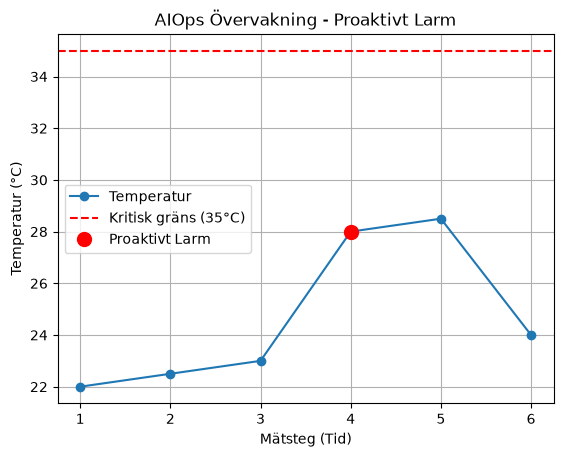

In [130]:
import matplotlib.pyplot as plt

# 1. TESTDATA OCH VARIABLER
matningar = [22.0, 22.5, 23.0, 28.0, "SKRAP_DATA", 28.5, 24.0]
tid_steg = []
giltiga_temp = []

tidigare_temp = None
larm_steg = None
larm_temp = None

# 2. BEARBETA DATA (FILTRERA OCH DETEKTERA LARM)
steg = 0
for matning in matningar:
    try:
        temp = float(matning)
    except ValueError:
        print(f"Hittade korrupt data: {matning} -> Hoppar över!")
        continue

    steg = steg + 1
    tid_steg.append(steg)
    giltiga_temp.append(temp)

    if tidigare_temp is not None:
        delta_t = temp - tidigare_temp
        if delta_t >= 3.0:
            print(f"LARM vid steg {steg}! Temperaturstegring: +{delta_t}°C")
            larm_steg = steg
            larm_temp = temp

    tidigare_temp = temp

# 3. RITA GRAFEN
plt.figure()

plt.plot(tid_steg, giltiga_temp, marker="o", label="Temperatur")
plt.axhline(35.0, color="red", linestyle="--", label="Kritisk gräns (35°C)")

if larm_steg is not None:
    plt.plot(larm_steg, larm_temp, "ro", markersize=10, label="Proaktivt Larm")

plt.title("AIOps Övervakning - Proaktivt Larm")
plt.xlabel("Mätsteg (Tid)")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()

plt.show()

--------------------------------------------------------------------
KORT SAMMANFATTNING SLIDING WINDOW 
AIOps Proaktiv övervakning via DCIM 
--------------------------------------------------------------------
Försök till ren tydlig kodstruktur. Loopen filtrerar bort
korrupt data med try/except och 'continue' så att grafen inte kraschar.
Samtidigt jämför den varje mätning med den förra (delta_t).

När temperaturen hoppar från 23 °C till 28 °C upptäcker koden en
ökning på +5 °C, sparar larmpunkten och ritar ut den som en röd punkt
vid 28 °C – långt innan den kritiska gränsen på 35 °C nås."